In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [3]:
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
DIR_DATA = path.join(DFS_ROOT, "2026_05_16_230759__sel_2prong-data-1e20")
# QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")

DIR_MC = path.join(DFS_ROOT, "2026_05_06_073032__sel_2prong-mc-BNB_cosmics")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_05_193232__sel_2prong-mc-Intime")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_05_233424__sel_2prong-data-OffBeamLight")
DIR_DIRT = path.join(DFS_ROOT, "2026_05_06_135816__sel_2prong-mc-dirt")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(
    save_fig_base_dir,
    f"data_mc_chi2_comparison_{today_str}",
)
# print("quality-cut df:", QUALITY_DF_PATH)
print("saving plots in", save_fig_dir)

saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260702


In [4]:
from pyanalib.split_df_helpers_new import dfs_from_dir

mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
intime_dfs = dfs_from_dir(
    DIR_INTIME,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
offbeam_dfs = dfs_from_dir(
    DIR_OFFBEAM,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
dirt_dfs = dfs_from_dir(
    DIR_DIRT,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
data_dfs = dfs_from_dir(
    DIR_DATA,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]

intime_evt_df = intime_dfs["evt"]
intime_hdr_df = intime_dfs["hdr"]

offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

dirt_evt_df = dirt_dfs["evt"]
dirt_hdr_df = dirt_dfs["hdr"]

data_evt_df = data_dfs["evt"]
data_hdr_df = data_dfs["hdr"]

print(f"mc:      evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}")
print(f"intime:  evt={len(intime_evt_df):,}  hdr={len(intime_hdr_df):,}")
print(f"offbeam: evt={len(offbeam_evt_df):,}  hdr={len(offbeam_hdr_df):,}")
print(f"dirt:    evt={len(dirt_evt_df):,}  hdr={len(dirt_hdr_df):,}")
print(f"data:    evt={len(data_evt_df):,}  hdr={len(data_hdr_df):,}")

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
dirt_evt_df.loc[dirt_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")

Found 999 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafpy

100%|██████████| 999/999 [08:40<00:00,  1.92it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232_

100%|██████████| 200/200 [01:40<00:00,  2.00it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamL

...

100%|██████████| 500/500 [03:38<00:00,  2.29it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_14.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel

100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc:      evt=725,456  hdr=3,187,761
intime:  evt=159,230  hdr=2,149,555
offbeam: evt=170,151  hdr=1,655,098
dirt:    evt=110,336  hdr=1,631,640
data:    evt=342,761  hdr=1,773,921
evt_good rows: 342,761


/tmp/ipykernel_2015281/3331057512.py:55: PerformanceWarning: indexing past lexsort depth may impact performance.
  mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
/tmp/ipykernel_2015281/3331057512.py:56: PerformanceWarning: indexing past lexsort depth may impact performance.
  dirt_evt_df.loc[dirt_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
/tmp/ipykernel_2015281/3331057512.py:58: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df[("mc", "iscc")] = 999


In [5]:
data_tot_pot = data_hdr_df["pot"].sum()
data_gates = data_hdr_df.nbnbinfo.sum()


pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print(f"mc_pot_scale: {mc_pot_scale:.3e}")
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

dirt_tot_pot = dirt_hdr_df["pot"].sum()
dirt_pot_scale = data_tot_pot / dirt_tot_pot
print(f"dirt_pot_scale: {dirt_pot_scale:.3e}")
dirt_evt_df["pot_weight"] = dirt_pot_scale * np.ones(len(dirt_evt_df))

intime_gates = intime_hdr_df[intime_hdr_df["first_in_subrun"] == 1]["ngenevt"].sum()
f = 0.08
scale_intime_to_lightdata = (1 - f) * data_gates / intime_gates
print(f"intime data scale: {scale_intime_to_lightdata:.2f}")
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

offbeam_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.08
scale_offbeam_to_lightdata = (1 - f) * data_gates / offbeam_gates
print(f"offbeam data scale: {scale_offbeam_to_lightdata:.2f}")
offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata * np.ones(len(offbeam_evt_df))

mc_pot_scale: 3.190e-01
dirt_pot_scale: 2.422e-01
intime data scale: 0.17
offbeam data scale: 0.22


/tmp/ipykernel_2015281/1345029260.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_evt_df["pot_weight"] = np.ones(len(data_evt_df))
/tmp/ipykernel_2015281/1345029260.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
/tmp/ipykernel_2015281/1345029260.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [6]:
for df in (mc_evt_df, data_evt_df, intime_evt_df, dirt_evt_df, offbeam_evt_df):
    df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk1", "pfp", "trk", "dir", "x", "", "")],
            df[("trk1", "pfp", "trk", "dir", "y", "", "")],
        )
    )
    df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk2", "pfp", "trk", "dir", "x", "", "")],
            df[("trk2", "pfp", "trk", "dir", "y", "", "")],
        )
    )

/tmp/ipykernel_2015281/3365631463.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_2015281/3365631463.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
/tmp/ipykernel_2015281/3365631463.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

In [7]:
for df in (mc_evt_df, data_evt_df, intime_evt_df, dirt_evt_df, offbeam_evt_df):
    # Get direction vectors for trk1 and trk2
    trk1_dir = np.stack([
        df[("trk1", "pfp", "trk", "dir", "x", "", "")],
        df[("trk1", "pfp", "trk", "dir", "y", "", "")],
        df[("trk1", "pfp", "trk", "dir", "z", "", "")]
    ], axis=1)
    trk2_dir = np.stack([
        df[("trk2", "pfp", "trk", "dir", "x", "", "")],
        df[("trk2", "pfp", "trk", "dir", "y", "", "")],
        df[("trk2", "pfp", "trk", "dir", "z", "", "")]
    ], axis=1)
    # Normalize
    trk1_norm = np.linalg.norm(trk1_dir, axis=1, keepdims=True)
    trk2_norm = np.linalg.norm(trk2_dir, axis=1, keepdims=True)
    trk1_dir_unit = np.divide(trk1_dir, trk1_norm, out=np.zeros_like(trk1_dir), where=trk1_norm!=0)
    trk2_dir_unit = np.divide(trk2_dir, trk2_norm, out=np.zeros_like(trk2_dir), where=trk2_norm!=0)
    # Compute cosine of angle between tracks
    costheta = np.sum(trk1_dir_unit * trk2_dir_unit, axis=1)
    # Clip for numerical safety
    costheta = np.clip(costheta, -1, 1)
    df[("tracks_cos_theta", "", "", "", "", "", "")] = costheta

/tmp/ipykernel_2015281/1493345759.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("tracks_cos_theta", "", "", "", "", "", "")] = costheta
/tmp/ipykernel_2015281/1493345759.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[("tracks_cos_theta", "", "", "", "", "", "")] = costheta
/tmp/ipykernel_2015281/1493345759.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat

In [8]:
# from pyanalib.variable_calculator import get_cc1p0pi_tki
# from pyanalib.pandas_helpers import pad_column_name

# def evt_df_fixed(df):
#     slc_mudf = df.mu.pfp.trk
#     slc_pdf = df.p.pfp.trk
#     tki_reco = get_cc1p0pi_tki(
#         slc_mudf,
#         slc_pdf,
#         pad_column_name(('P', 'p_muon'), slc_mudf),
#         pad_column_name(('P', 'p_proton'), slc_pdf),
#     )
#     df['del_Tp_x'] = tki_reco['del_Tp_x']
#     df['del_Tp_y'] = tki_reco['del_Tp_y']

#     mc_mudf = df.mu.pfp.trk.truth.p
#     mc_pdf = df.p.pfp.trk.truth.p
#     tki_mc = get_cc1p0pi_tki(
#         mc_mudf,
#         mc_pdf,
#         pad_column_name(('totp',), mc_mudf),
#         pad_column_name(('totp',), mc_pdf),
#     )
#     df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
#     df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
#     df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
#     df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

#     n_before = len(df)
#     df = df[np.abs(df.slc.vertex.x) > 10]
#     if 'topo_categ' not in df.columns:
#         df = df.copy()
#         df.loc[:, 'topo_categ'] = get_topo_category(df)
#     return df, n_before


# mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)
# data_evt_df, n_evt_before_fv = evt_df_fixed(data_evt_df)
# intime_evt_df, n_evt_before_fv = evt_df_fixed(intime_evt_df)
# offbeam_evt_df, n_evt_before_fv = evt_df_fixed(offbeam_evt_df)

In [9]:
# Event selection
from analysis_village.numucc_1p0pi.makedf.selections import *

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)


mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

In [10]:
perTPC_inset = 10

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df_gen1 = mc_evt_df.loc[perTPC_cut(mc_evt_df)]
dirt_evt_df_gen1 = dirt_evt_df.loc[perTPC_cut(dirt_evt_df)]
intime_evt_df_gen1 = intime_evt_df.loc[perTPC_cut(intime_evt_df)]
offbeam_evt_df_gen1 = offbeam_evt_df.loc[perTPC_cut(offbeam_evt_df)]
data_evt_df_gen1 = data_evt_df.loc[perTPC_cut(data_evt_df)]

print(f"perTPC: data={len(data_evt_df):,} mc={len(mc_evt_df):,} intime={len(intime_evt_df):,} dirt={len(dirt_evt_df):,} offbeam={len(offbeam_evt_df):,}")

perTPC: data=50,145 mc=141,484 intime=12,153 dirt=9,394 offbeam=10,268


In [11]:
def get_octant_dfs(df):
    """
    Splits a DataFrame into 8 octants based on slc.vertex.x, slc.vertex.y, and slc.vertex.z.
    Dividers are x=0, y=0, z=250.
    Returns a list of 8 DataFrames, one for each octant.
    """
    octants = []
    for i in range(8):
        mask_x = (df.slc.vertex.x >= 0) if ((i >> 2) & 1) else (df.slc.vertex.x < 0)
        mask_y = (df.slc.vertex.y >= 0) if ((i >> 1) & 1) else (df.slc.vertex.y < 0)
        mask_z = (df.slc.vertex.z >= 250) if ((i >> 0) & 1) else (df.slc.vertex.z < 250)
        mask = mask_x & mask_y & mask_z
        octants.append(df[mask])
    return octants

# List of octant titles in matching order
octant_titles = [
    "x<0, y<0, z<250",
    "x<0, y<0, z>=250",
    "x<0, y>=0, z<250",
    "x<0, y>=0, z>=250",
    "x>=0, y<0, z<250",
    "x>=0, y<0, z>=250",
    "x>=0, y>=0, z<250",
    "x>=0, y>=0, z>=250",
]

In [12]:
# some additional cuts



In [13]:
mc_evt_df_octants = get_octant_dfs(mc_evt_df)
data_evt_df_octants = get_octant_dfs(data_evt_df)
intime_evt_df_octants = get_octant_dfs(intime_evt_df)
offbeam_evt_df_octants = get_octant_dfs(offbeam_evt_df)
dirt_evt_df_octants = get_octant_dfs(dirt_evt_df)

mc_evt_df_octants_gen1 = get_octant_dfs(mc_evt_df_gen1)
data_evt_df_octants_gen1 = get_octant_dfs(data_evt_df_gen1)
intime_evt_df_octants_gen1 = get_octant_dfs(intime_evt_df_gen1)
offbeam_evt_df_octants_gen1 = get_octant_dfs(offbeam_evt_df_gen1)
dirt_evt_df_octants_gen1 = get_octant_dfs(dirt_evt_df_gen1)

# mc_evt_df_octants_gen1 = get_octant_dfs(mc_evt_df)
# data_evt_df_octants_gen1 = get_octant_dfs(data_evt_df)
# intime_evt_df_octants_gen1 = get_octant_dfs(intime_evt_df)
# offbeam_evt_df_octants_gen1 = get_octant_dfs(offbeam_evt_df)
# dirt_evt_df_octants_gen1 = get_octant_dfs(dirt_evt_df)

In [14]:
plt.rcParams['figure.dpi'] = 300

In [33]:
PANEL_COLS_MAX = 4
PANEL_COL_W_IN = 5.0
PANEL_ROW_H_IN = 5.0
OCTANT_GRIDSPEC = {"hspace": 0.35, "wspace": 0.30}


@contextlib.contextmanager
def _patch_overlay_axes(fig, ax_rate, ax_ratio):
    """Draw overlay_hists on pre-allocated axes (rate + ratio panels)."""
    _orig_subplots = plt.subplots
    _orig_close = plt.close

    def _subplots(*args, **kwargs):
        if kwargs.get("gridspec_kw") is not None:
            return fig, [ax_rate, ax_ratio]
        return fig, ax_rate

    def _close(_fig=None):
        return None

    plt.subplots = _subplots
    plt.close = _close
    try:
        yield
    finally:
        plt.subplots = _orig_subplots
        plt.close = _orig_close


def octant_grid_figsize(n_row_panels, n_cols):
    return (PANEL_COL_W_IN * n_cols, PANEL_ROW_H_IN * n_row_panels)


def panel_grid_shape(n_panels, n_cols_max=PANEL_COLS_MAX):
    n_cols = min(n_cols_max, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    return n_rows, n_cols


def _style_octant_axes(ax_rate, ax_ratio, show_legend=True):
    ax_rate.tick_params(axis="both", labelsize=9)
    ax_ratio.tick_params(axis="both", labelsize=9)
    leg = ax_rate.get_legend()
    if leg is not None:
        if show_legend:
            for txt in leg.get_texts():
                txt.set_fontsize(7)
            if hasattr(leg, "set_ncols"):
                leg.set_ncols(2)
            leg.set_bbox_to_anchor((0.02, 0.98))
        else:
            leg.remove()


def draw_octant_overlay_panel(fig, ax_rate, ax_ratio, overlay_kwargs, show_legend=True):
    with _patch_overlay_axes(fig, ax_rate, ax_ratio):
        ret = overlay_hists(**overlay_kwargs, plot=False, save_fig=False)
    subtitle = overlay_kwargs.get("plot_labels", ["", "", ""])[2]
    ax_rate.set_title(subtitle, fontsize=10, pad=4)
    _style_octant_axes(ax_rate, ax_ratio, show_legend=show_legend)
    return ret


def cosmic_content_fraction(offbeam_df=None, mc_df=None):
    """Cosmic content of the prediction: ratio of pot-weighted total entries
    in offbeam_evt_df to pot-weighted total entries in mc_evt_df."""
    if offbeam_df is None:
        offbeam_df = offbeam_evt_df
    if mc_df is None:
        mc_df = mc_evt_df
    return offbeam_df.pot_weight.sum() / mc_df.pot_weight.sum()


def cosmic_frac_cov(intime_df, offbeam_df, var_config, cosmic_frac=None):
    """Cosmic-model fractional covariance from the intime vs offbeam difference.

    Histogram both cosmic samples with their pot_weight scaling, take the
    per-bin fractional difference |intime - offbeam| / offbeam as the
    uncertainty, and scale it by the cosmic content fraction (offbeam total /
    mc total) so the fraction is relative to the TOTAL prediction, not the
    cosmic component alone. The square goes on the diagonal. Units match the
    syst npy files: a FRACTIONAL covariance, to be summed with them before
    overlay_hists multiplies by the total event rate.
    """
    v_int, w_int = get_clipped_evts(intime_df, var_config.var_evt_reco_col, var_config.bins)
    v_off, w_off = get_clipped_evts(offbeam_df, var_config.var_evt_reco_col, var_config.bins)
    n_int = np.histogram(v_int, bins=var_config.bins, weights=w_int)[0]
    n_off = np.histogram(v_off, bins=var_config.bins, weights=w_off)[0]
    frac = np.divide(
        np.abs(n_int - n_off),
        n_off,
        out=np.zeros_like(n_off, dtype=float),
        where=n_off > 0,
    )
    if cosmic_frac is None:
        cosmic_frac = cosmic_content_fraction()
    frac = frac * cosmic_frac
    return np.diag(frac**2)


def plot_cosmic_syst_octants(var_config, intime_octants, offbeam_octants):
    """Diagnostic: pot-weighted intime vs offbeam distributions per octant,
    with the resulting fractional uncertainty on a twin axis."""
    n_oct = len(octant_titles)
    n_row_panels, n_cols = panel_grid_shape(n_oct)
    fig, axes = plt.subplots(
        n_row_panels,
        n_cols,
        figsize=octant_grid_figsize(n_row_panels, n_cols),
        sharex=True,
    )
    axes = np.atleast_2d(axes)
    bin_centers = 0.5 * (var_config.bins[:-1] + var_config.bins[1:])
    for i in range(n_oct):
        ax = axes[divmod(i, n_cols)]
        v_int, w_int = get_clipped_evts(intime_octants[i], var_config.var_evt_reco_col, var_config.bins)
        v_off, w_off = get_clipped_evts(offbeam_octants[i], var_config.var_evt_reco_col, var_config.bins)
        n_int = np.histogram(v_int, bins=var_config.bins, weights=w_int)[0]
        n_off = np.histogram(v_off, bins=var_config.bins, weights=w_off)[0]
        ax.step(bin_centers, n_int, where="mid", color="tab:blue", label="intime")
        ax.step(bin_centers, n_off, where="mid", color="tab:orange", label="offbeam")
        ax.set_title(octant_titles[i], fontsize=10)
        ax.tick_params(axis="both", labelsize=9)
        frac = np.sqrt(np.diag(cosmic_frac_cov(intime_octants[i], offbeam_octants[i], var_config)))
        ax_f = ax.twinx()
        ax_f.plot(bin_centers, frac, color="red", linewidth=0.8, alpha=0.7, label="frac. unc.")
        ax_f.set_ylim(0, min(np.nanmax(frac) * 1.2 + 1e-3, 3.0))
        ax_f.tick_params(axis="y", labelsize=8, colors="red")
        if i == 0:
            ax.legend(fontsize=7, loc="upper right")
    fig.suptitle(f"cosmic syst input: {var_config.var_save_name}", fontsize=12)
    fig.tight_layout()
    plt.show()
    return fig


def plot_all_octants(
    plot_type,
    var_config,
    mc_octants,
    data_octants,
    intime_octants,
    dirt_octants=None,
    suffix="",
    ylabel="Tracks / Bin",
    ax_ylim_ratio=1.8,
    syst_per_octant=None,
    show_shape_chi2=False,
    add_cosmic_syst=True,
    cosmic_intime_octants=None,
    cosmic_offbeam_octants=None,
    syst_npy=None,
    **overlay_extra,
):
    """Plot all 8 octant overlays in one figure (2x4 panel grid)."""
    # Cosmic syst needs BOTH intime and offbeam octants (the third positional
    # arg is only whichever cosmic estimate is drawn in the stack). Default to
    # the module-level octant lists matching the gen1/non-gen1 selection.
    if add_cosmic_syst and (cosmic_intime_octants is None or cosmic_offbeam_octants is None):
        if "gen1" in suffix:
            cosmic_intime_octants = intime_evt_df_octants_gen1
            cosmic_offbeam_octants = offbeam_evt_df_octants_gen1
        else:
            cosmic_intime_octants = intime_evt_df_octants
            cosmic_offbeam_octants = offbeam_evt_df_octants

    n_oct = len(octant_titles)
    n_row_panels, n_cols = panel_grid_shape(n_oct)
    n_gs_rows = 2 * n_row_panels

    fig, axes = plt.subplots(
        n_gs_rows,
        n_cols,
        figsize=octant_grid_figsize(n_row_panels, n_cols),
        sharex=True,
        gridspec_kw={
            "height_ratios": [3, 1] * n_row_panels,
            **OCTANT_GRIDSPEC,
        },
    )
    if n_cols == 1:
        axes = np.array(axes).reshape(n_gs_rows, 1)

    for i in range(n_oct):
        row_p, col = divmod(i, n_cols)
        ax_rate = axes[2 * row_p, col]
        ax_ratio = axes[2 * row_p + 1, col]

        kwargs = dict(
            breakdown_type=plot_type,
            mc_df=mc_octants[i],
            data_df=data_octants[i],
            intime_df=intime_octants[i],
            ratio=True,
            ax_ylim_ratio=ax_ylim_ratio,
            var_config=var_config,
            plot_labels=[var_config.var_labels[0], ylabel, octant_titles[i]],
            textchi2=False,
            approval="",
        )
        if dirt_octants is not None:
            kwargs["dirt_df"] = dirt_octants[i]
        if syst_per_octant is not None:
            kwargs["syst"] = syst_per_octant(i)
        loaded_syst = np.load(resolve_syst_npy(var_config, syst_npy), allow_pickle=True)
        syst_total = np.asarray(loaded_syst, dtype=float)
        if add_cosmic_syst:
            # both are fractional covariances: sum BEFORE overlay_hists
            # multiplies by the total event rate
            syst_total = syst_total + cosmic_frac_cov(
                cosmic_intime_octants[i], cosmic_offbeam_octants[i], var_config
            )
        kwargs["syst"] = syst_total
        kwargs.update(overlay_extra)

        ret = draw_octant_overlay_panel(
            fig, ax_rate, ax_ratio, kwargs, show_legend=True
        )

        chi2_val = ret.get("chi2_val") if ret is not None else None
        p_val = ret.get("p_val") if ret is not None else None
        ndof = ret.get("ndof") if ret is not None else None
        chi2_shape_val = ret.get("chi2_shape_val") if ret is not None else None
        p_val_shape = ret.get("p_val_shape") if ret is not None else None
        if chi2_val is not None and p_val is not None and ndof is not None:
            ax_rate.text(
                0.97, 0.65,
                f"$\\chi^2$/ndof = {chi2_val:.1f}/{int(ndof)}\n(p-value = {p_val:.2f})",
                transform=ax_rate.transAxes,
                ha="right", va="top",
                fontsize=7,
                color="black",
            )
        if show_shape_chi2 and chi2_shape_val is not None and p_val_shape is not None and ndof is not None:
            ax_rate.text(
                0.97, 0.53,
                f"shape-only $\\chi^2$/ndof = {chi2_shape_val:.1f}/{int(ndof) - 1}\n(p-value = {p_val_shape:.2f})",
                transform=ax_rate.transAxes,
                ha="right", va="top",
                fontsize=7,
                color="black",
            )

        if col == 0:
            ax_rate.set_ylabel(ylabel)
            ax_ratio.set_ylabel("Data/MC")
        ax_ratio.axhline(1.0, color="red", linestyle="--", linewidth=0.8)

    for k in range(n_oct, n_row_panels * n_cols):
        row_p, col = divmod(k, n_cols)
        axes[2 * row_p, col].set_visible(False)
        axes[2 * row_p + 1, col].set_visible(False)

    fig.subplots_adjust(top=0.94, bottom=0.06, left=0.06, right=0.99)

    if save_fig:
        save_name = save_fig_dir + "/2prong-{}_{}-octants{}.png".format(
            var_config.var_save_name, plot_type, suffix
        )
        fig.savefig(save_name + fig_ext, bbox_inches="tight", dpi=dpi)
        print("saved", save_name + fig_ext)

    plt.show()
    return fig


def cosmic_frac_cov_octant_gen1(i, var_config):
    var_offbeam = get_clipped_evts(
        offbeam_evt_df_octants_gen1[i], var_config.var_evt_reco_col, var_config.bins
    )[0]
    var_intime = get_clipped_evts(
        intime_evt_df_octants_gen1[i], var_config.var_evt_reco_col, var_config.bins
    )[0]
    n_offbeam = np.histogram(var_offbeam, bins=var_config.bins)[0] * offbeam_evt_df.pot_weight.unique()[0]
    n_intime = np.histogram(var_intime, bins=var_config.bins)[0] * intime_evt_df.pot_weight.unique()[0]
    frac_unc = np.abs(n_intime - n_offbeam) / n_offbeam
    return np.diag(frac_unc)


# ==== 3-plane averaged chi2: columns + var configs matching the syst npy ====
# The syst npy files (syst_array_chi2*.npy) are produced by get_syst(...) in
# event_selection-from_2prong.ipynb. Their bin axis is the EVT config binning
# (chi2_mu(): 0-60, chi2_proton(): 0-350, 60 bins) and their variable is the
# 3-PLANE AVERAGED chi2 (avg_chi2: 0 -> NaN, mean over I0/I1/I2), stacked over
# trk1+trk2. A fractional covariance is applied bin-by-bin, so panels using it
# MUST plot the same variable with the same bin edges — NOT the I2-only chi2
# and NOT the 0-300 trk binning, otherwise the syst band shape is distorted.

def add_avg_chi2_cols(df, trks=("trk1", "trk2"), var_names=("chi2_muon", "chi2_proton")):
    """Add (trkX, pfp, trk, chi2pid, avg, ...) columns, same as makedf.util.avg_chi2."""
    for trk in trks:
        for var in var_names:
            col_avg = (trk, "pfp", "trk", "chi2pid", "avg", var, "")
            if col_avg in df.columns:
                continue
            planes = pd.concat(
                [df[(trk, "pfp", "trk", "chi2pid", pl, var, "")] for pl in ("I0", "I1", "I2")],
                axis=1,
            ).replace(0, np.nan)
            df[col_avg] = planes.mean(axis=1, skipna=True)


with pd.option_context("mode.chained_assignment", None):
    for _octants in (
        mc_evt_df_octants, data_evt_df_octants, intime_evt_df_octants,
        offbeam_evt_df_octants, dirt_evt_df_octants,
        mc_evt_df_octants_gen1, data_evt_df_octants_gen1, intime_evt_df_octants_gen1,
        offbeam_evt_df_octants_gen1, dirt_evt_df_octants_gen1,
    ):
        for _df in _octants:
            add_avg_chi2_cols(_df)


def avg_chi2_var_config(trk, particle):
    """VariableConfig for the 3-plane averaged chi2 of one track, with the
    variable and bin axis matching the syst npy (chi2_mu()/chi2_proton())."""
    base = VariableConfig.chi2_mu() if particle == "mu" else VariableConfig.chi2_proton()
    var = "chi2_muon" if particle == "mu" else "chi2_proton"
    return VariableConfig(
        var_save_name=f"{trk}_{base.var_save_name}_avg",
        var_plot_name=base.var_plot_name,
        var_labels=list(base.var_labels),
        bins=base.bins,
        var_evt_reco_col=(trk, "pfp", "trk", "chi2pid", "avg", var, ""),
        var_evt_truth_col=(trk, "pfp", "trk", "chi2pid", "avg", var, ""),
        var_nu_col=("", "", ""),
        xsec_label=base.xsec_label,
    )


def resolve_syst_npy(var_config, syst_npy=None):
    """Pick the syst npy saved by event_selection-from_2prong get_syst()."""
    if syst_npy is not None:
        return syst_npy
    # mu: 0-60 (61 edges); proton: 0-350 (61 edges) — same n_bins, different axis
    if var_config.bins[-1] > 100:
        return "syst_array_chi2proton.npy"
    return "syst_array_chi2mu.npy"


# ---- octant ratio overlay colors (edit cmap / indices here) ----
# x<0 octants (indices 0-3) and x>=0 octants (indices 4-7) use separate palettes.
OCTANT_RATIO_CMAP_NEG_X = plt.cm.tab20b
OCTANT_RATIO_CMAP_POS_X = plt.cm.tab20c


def octant_ratio_color(i):
    """Return color for octant i (see OCTANT_RATIO_CMAP_* above)."""
    if i < 4:
        return OCTANT_RATIO_CMAP_NEG_X(i+4)
    return OCTANT_RATIO_CMAP_POS_X(i)


def plot_octants_ratio_overlay(
    plot_type,
    var_config,
    mc_octants,
    data_octants,
    intime_octants,
    dirt_octants=None,
    suffix="",
    syst_npy=None,
    ax_ylim_ratio=1.8,
    ylabel="Data/MC",
    **overlay_extra,
):
    """Overlay all octant Data/MC ratio spectra on one axis (ratio panel only).

    Uses the syst covariance from the npy file only (no per-octant cosmic add-on).
    Each octant is a different color with its octant_titles label in the legend.
    """
    syst_frac = np.asarray(
        np.load(resolve_syst_npy(var_config, syst_npy), allow_pickle=True), dtype=float
    )
    syst_err_ratio = np.sqrt(np.maximum(np.diag(syst_frac), 0.0))
    bin_centers = var_config.bin_centers
    bins = var_config.bins
    n_oct = len(octant_titles)

    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8, zorder=0)
    ax.bar(
        bin_centers,
        2 * syst_err_ratio,
        width=np.diff(bins),
        bottom=1.0 - syst_err_ratio,
        facecolor="none",
        hatch="xxx",
        linewidth=0.0,
        edgecolor="lightgray",
        label="Syst. unc.",
        zorder=1,
    )

    for i in range(n_oct):
        kwargs = dict(
            breakdown_type=plot_type,
            mc_df=mc_octants[i],
            data_df=data_octants[i],
            intime_df=intime_octants[i],
            ratio=True,
            ax_ylim_ratio=ax_ylim_ratio,
            var_config=var_config,
            plot_labels=[var_config.var_labels[0], ylabel, octant_titles[i]],
            syst=syst_frac,
            textchi2=False,
            approval="",
            plot=False,
            save_fig=False,
        )
        if dirt_octants is not None:
            kwargs["dirt_df"] = dirt_octants[i]
        kwargs.update(overlay_extra)

        ret = overlay_hists(**kwargs)
        total_mc = np.asarray(ret["total_mc"], dtype=float)
        total_data = np.asarray(ret["total_data"], dtype=float)
        ratio = np.divide(
            total_data, total_mc, out=np.zeros_like(total_mc), where=total_mc > 0
        )
        data_eylow, data_eyhigh = return_data_stat_err(total_data)
        ratio_eylow = np.divide(
            data_eylow, total_mc, out=np.zeros_like(total_mc), where=total_mc > 0
        )
        ratio_eyhigh = np.divide(
            data_eyhigh, total_mc, out=np.zeros_like(total_mc), where=total_mc > 0
        )
        ax.errorbar(
            bin_centers,
            ratio,
            yerr=np.vstack((ratio_eylow, ratio_eyhigh)),
            fmt="o",
            linestyle="none",
            color=octant_ratio_color(i),
            markersize=4.032,
            capsize=2.688,
            elinewidth=1.344,
            markeredgewidth=0.8064,
            label=octant_titles[i],
            zorder=3 + i,
        )

    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0.0, ax_ylim_ratio)
    ax.set_xlabel(var_config.var_labels[0], fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, which="major", linestyle="-", linewidth=0.5, alpha=0.5)
    ax.minorticks_on()
    ax.legend(
        fontsize=7,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        framealpha=0.9,
    )
    fig.subplots_adjust(right=0.72)

    if save_fig:
        save_name = save_fig_dir + "/2prong-{}_{}-ratio-octants-overlay{}.png".format(
            var_config.var_save_name, plot_type, suffix
        )
        fig.savefig(save_name + fig_ext, bbox_inches="tight", dpi=dpi)
        print("saved", save_name + fig_ext)

    plt.show()
    return fig, ax


def plot_octants_ratio_overlay_both_trks(
    plot_type,
    var_config_trk1,
    var_config_trk2,
    mc_octants,
    data_octants,
    intime_octants,
    dirt_octants=None,
    var_save_name="trk1trk2",
    var_label="trk1 + trk2",
    **plot_kwargs,
):
    """Like plot_octants_ratio_overlay, with trk1 and trk2 stacked per octant."""
    from analysis_village.numucc_1p0pi.selection_framework import multicol_get_series

    def stack(df):
        col_trk1 = var_config_trk1.var_evt_reco_col
        col_trk2 = var_config_trk2.var_evt_reco_col
        df_trk2 = df.copy()
        df_trk2[col_trk1] = multicol_get_series(df, col_trk2).to_numpy()
        return pd.concat([df, df_trk2])

    var_config_both = VariableConfig(
        var_save_name=var_save_name,
        var_plot_name=var_config_trk1.var_plot_name,
        var_labels=[var_label] + list(var_config_trk1.var_labels[1:]),
        bins=var_config_trk1.bins,
        var_evt_reco_col=var_config_trk1.var_evt_reco_col,
        var_evt_truth_col=var_config_trk1.var_evt_truth_col,
        var_nu_col=var_config_trk1.var_nu_col,
        xsec_label=var_config_trk1.xsec_label,
    )
    return plot_octants_ratio_overlay(
        plot_type,
        var_config_both,
        [stack(df) for df in mc_octants],
        [stack(df) for df in data_octants],
        [stack(df) for df in intime_octants],
        dirt_octants=None if dirt_octants is None else [stack(df) for df in dirt_octants],
        **plot_kwargs,
    )

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3246: RuntimeWarning: divide by zero encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3246: RuntimeWarning: invalid value encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3247: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3248: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3494: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc # dummy
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysi

FileNotFoundError: [Errno 2] No such file or directory: '/exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260702/2prong-trk2_chi2_mu_avg_topology-octants-gen1.png.png'

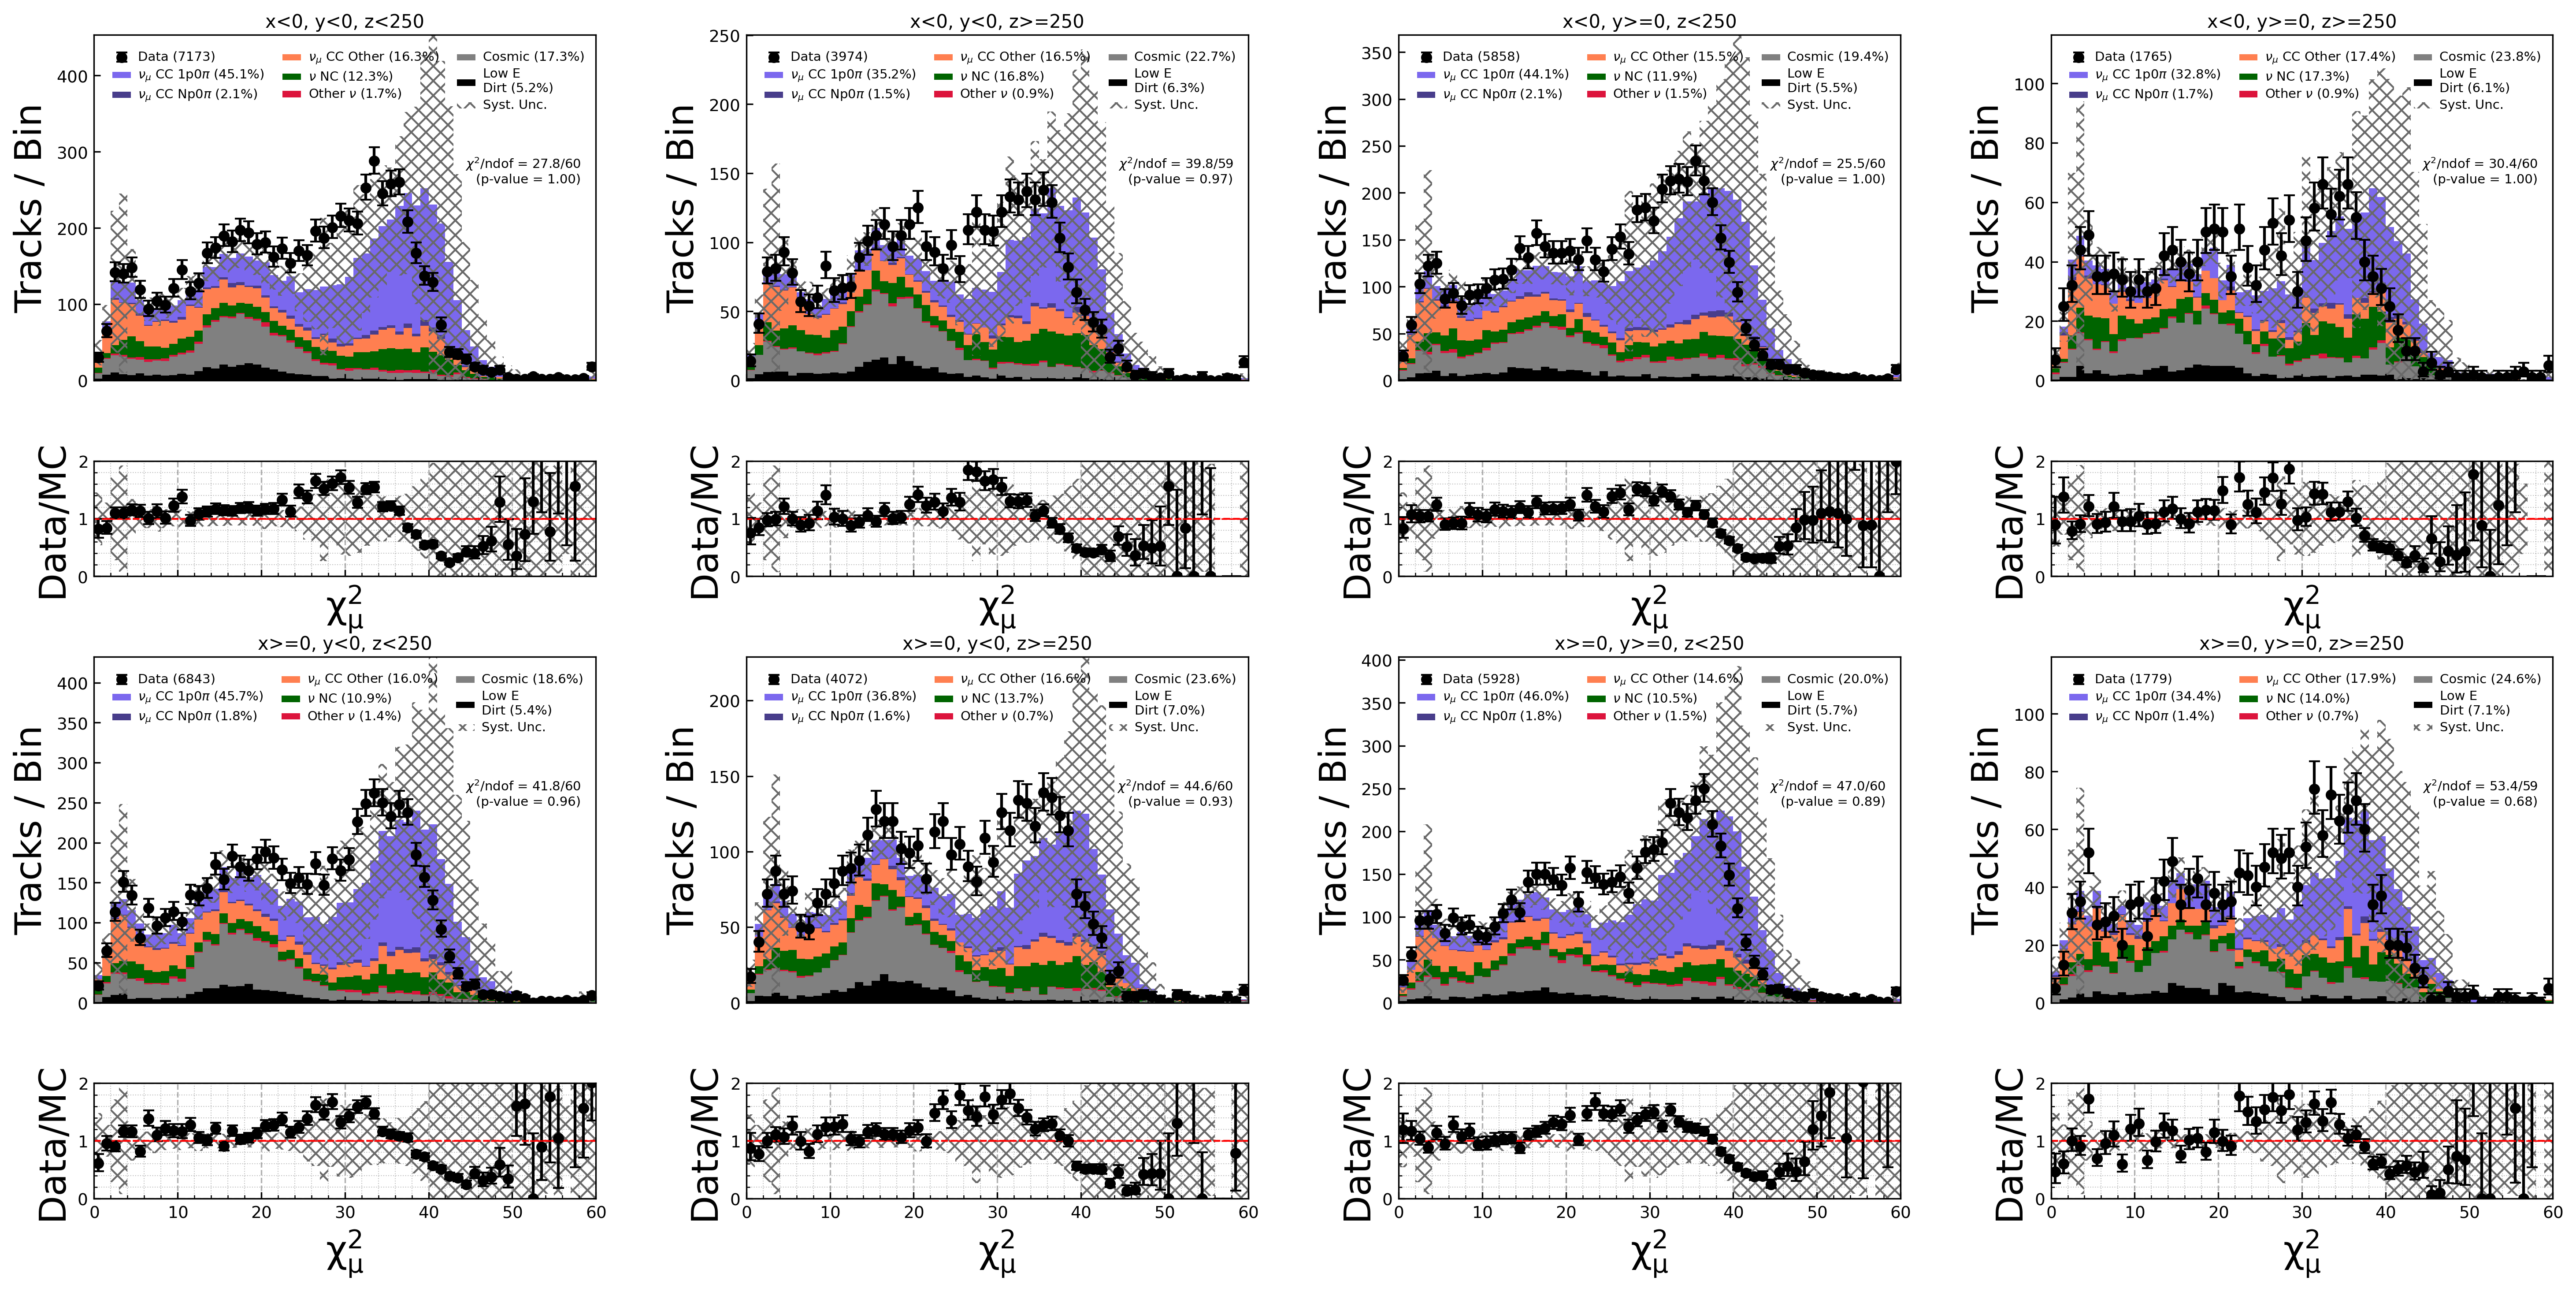

In [16]:
# trk2 chi2_mu per octant
# 3-plane avg chi2 with chi2_mu() bins (0-60): matches syst_array_chi2mu.npy
plot_type = "topology"

var_config = avg_chi2_var_config("trk2", "mu")

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
);

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3246: RuntimeWarning: divide by zero encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3246: RuntimeWarning: invalid value encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3247: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3248: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3494: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc # dummy
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysi

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260702/2prong-trk2_chi2_p_avg_topology-octants-gen1.png.png


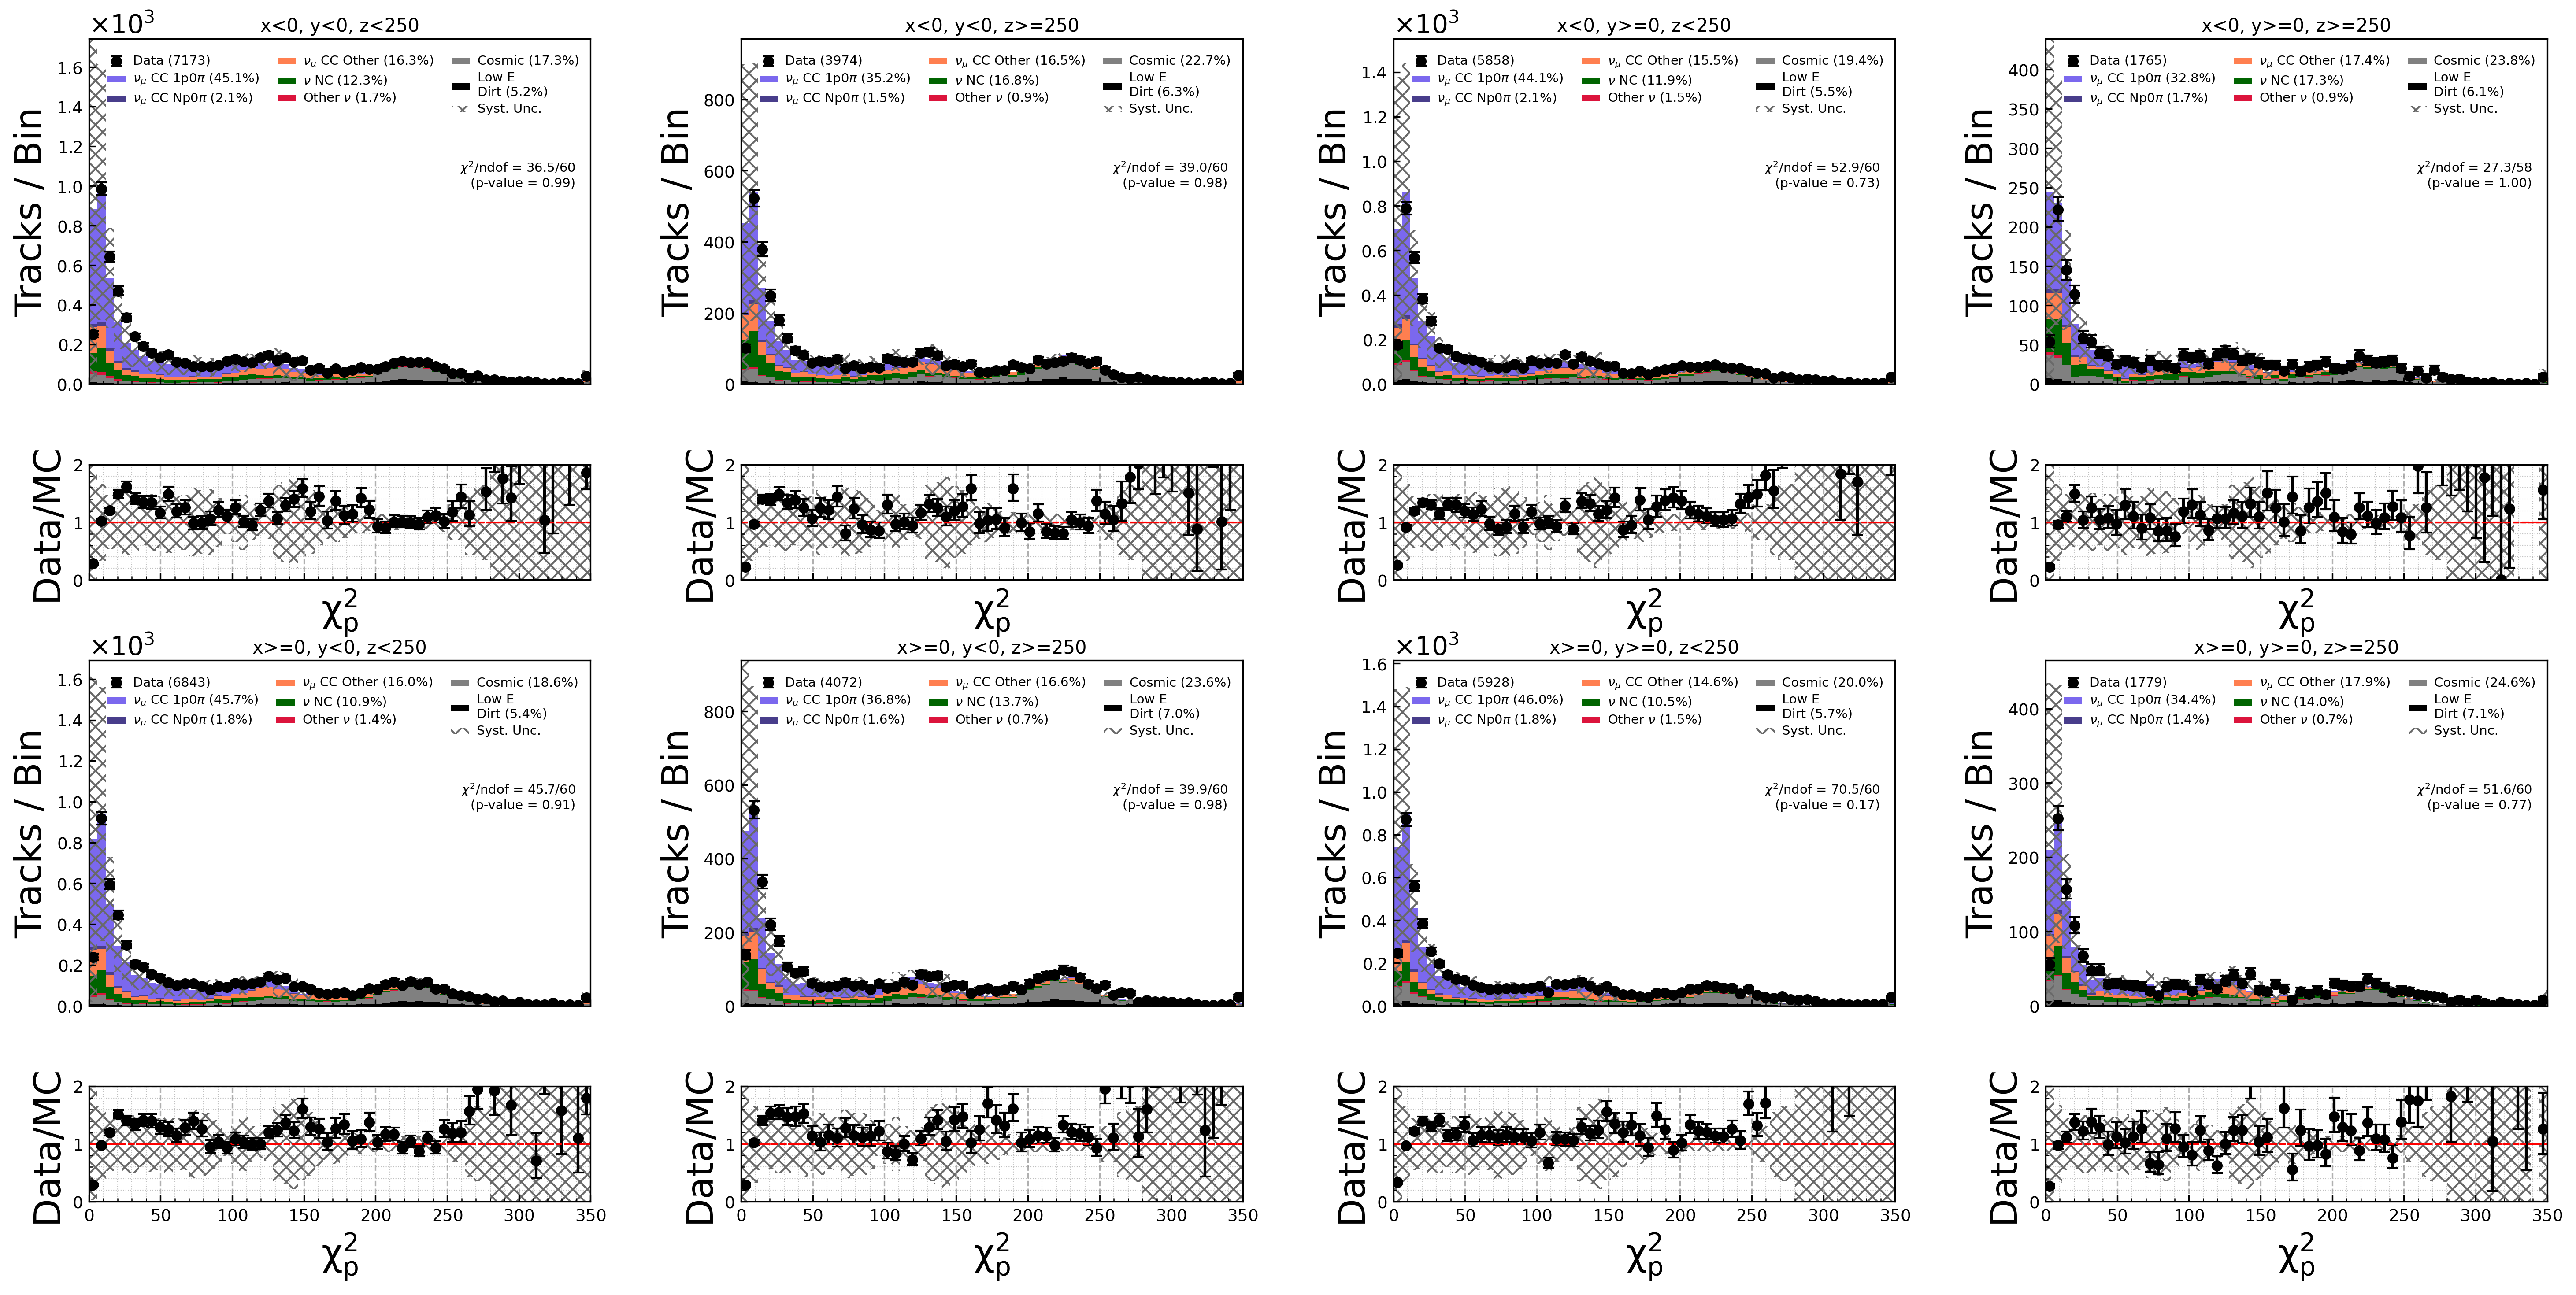

In [17]:
# trk2 chi2_proton per octant
# 3-plane avg chi2 with chi2_proton() bins (0-350): matches the variable and
# bin axis of syst_array_chi2proton.npy (see note in the definitions cell)
plot_type = "topology"

var_config = avg_chi2_var_config("trk2", "proton")

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
);

In [19]:
# plot trk1 AND trk2 chi2_mu combined in a single panel per octant
from analysis_village.numucc_1p0pi.selection_framework import multicol_get_series


def stack_trk1_trk2(df, var_config_trk1, var_config_trk2):
    """Stack a df with itself so each event contributes two track entries.

    The second copy carries the trk2 value in the trk1 column, so a single
    VariableConfig pointing at the trk1 column histograms both tracks.
    All other columns (truth categories, pot_weight, vertex, ...) are
    duplicated row-wise, so the topology breakdown and octant machinery
    in overlay_hists work unchanged.
    """
    col_trk1 = var_config_trk1.var_evt_reco_col
    col_trk2 = var_config_trk2.var_evt_reco_col
    df_trk2 = df.copy()
    df_trk2[col_trk] = multicol_get_series(df, col_trk2).to_numpy()
    return pd.concat([df, df_trk2])


def both_trks_var_config(var_config_trk1, var_save_name, var_label):
    """VariableConfig reading the trk1 column (holding trk1+trk2 values
    after stacking) with combined naming/labels."""
    return VariableConfig(
        var_save_name=var_save_name,
        var_plot_name=var_config_trk1.var_plot_name,
        var_labels=[var_label] + list(var_config_trk1.var_labels[1:]),
        bins=var_config_trk1.bins,
        var_evt_reco_col=var_config_trk1.var_evt_reco_col,
        var_evt_truth_col=var_config_trk1.var_evt_truth_col,
        var_nu_col=var_config_trk1.var_nu_col,
        xsec_label=var_config_trk1.xsec_label,
    )


def plot_all_octants_both_trks(
    plot_type,
    var_config_trk1,
    var_config_trk2,
    mc_octants,
    data_octants,
    intime_octants,
    dirt_octants=None,
    offbeam_octants=None,
    var_save_name="trk1trk2",
    var_label="trk1 + trk2",
    **plot_kwargs,
):
    """Same as plot_all_octants, but each panel contains both trk1 and trk2
    entries (every event contributes two tracks to the histograms).

    offbeam_octants: needed for the cosmic syst (intime vs offbeam fractional
    difference); it is stacked the same way as the plotted samples so the
    cosmic frac cov is computed on trk1+trk2 entries. Defaults to the
    module-level gen1/non-gen1 offbeam octant lists based on ``suffix``.
    """
    stack = lambda df: stack_trk1_trk2(df, var_config_trk1, var_config_trk2)
    var_config_both = both_trks_var_config(var_config_trk1, var_save_name, var_label)
    if plot_kwargs.get("add_cosmic_syst", True):
        gen1 = "gen1" in plot_kwargs.get("suffix", "")
        cosmic_intime = intime_evt_df_octants_gen1 if gen1 else intime_evt_df_octants
        if offbeam_octants is None:
            offbeam_octants = offbeam_evt_df_octants_gen1 if gen1 else offbeam_evt_df_octants
        plot_kwargs.setdefault("cosmic_intime_octants", [stack(df) for df in cosmic_intime])
        plot_kwargs.setdefault("cosmic_offbeam_octants", [stack(df) for df in offbeam_octants])
    return plot_all_octants(
        plot_type,
        var_config_both,
        [stack(df) for df in mc_octants],
        [stack(df) for df in data_octants],
        [stack(df) for df in intime_octants],
        dirt_octants=None if dirt_octants is None else [stack(df) for df in dirt_octants],
        **plot_kwargs,
    )


plot_type = "topology"

# 3-plane avg chi2_mu, trk1 + trk2 in one panel per octant
plot_all_octants_both_trks(
    plot_type,
    avg_chi2_var_config("trk1", "mu"),
    avg_chi2_var_config("trk2", "mu"),
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    var_save_name="trk1trk2_chi2_mu",
    var_label=r"$\mathrm{\chi^{2}_{\mu}}$",
    suffix="-gen1",
);

# 3-plane avg chi2_proton, trk1 + trk2 in one panel per octant
plot_all_octants_both_trks(
    plot_type,
    avg_chi2_var_config("trk1", "proton"),
    avg_chi2_var_config("trk2", "proton"),
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    var_save_name="trk1trk2_chi2_proton",
    var_label=r"$\mathrm{\chi^{2}_{p}}$",
    suffix="-gen1",
);

NameError: name 'col_trk' is not defined

/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3246: RuntimeWarning: divide by zero encountered in divide
  data_ratio = total_data / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3247: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = data_eylow / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3248: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3494: RuntimeWarning: invalid value encountered in divide
  mc_content_ratio = total_mc / total_mc # dummy
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/utils.py:3495: RuntimeWarning: invalid value encountered in divide
  mc_stat_err_ratio = syst_err / total_mc
/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/en

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260702/2prong-trk1trk2_chi2_mu_topology-ratio-octants-overlay-gen1.png.png


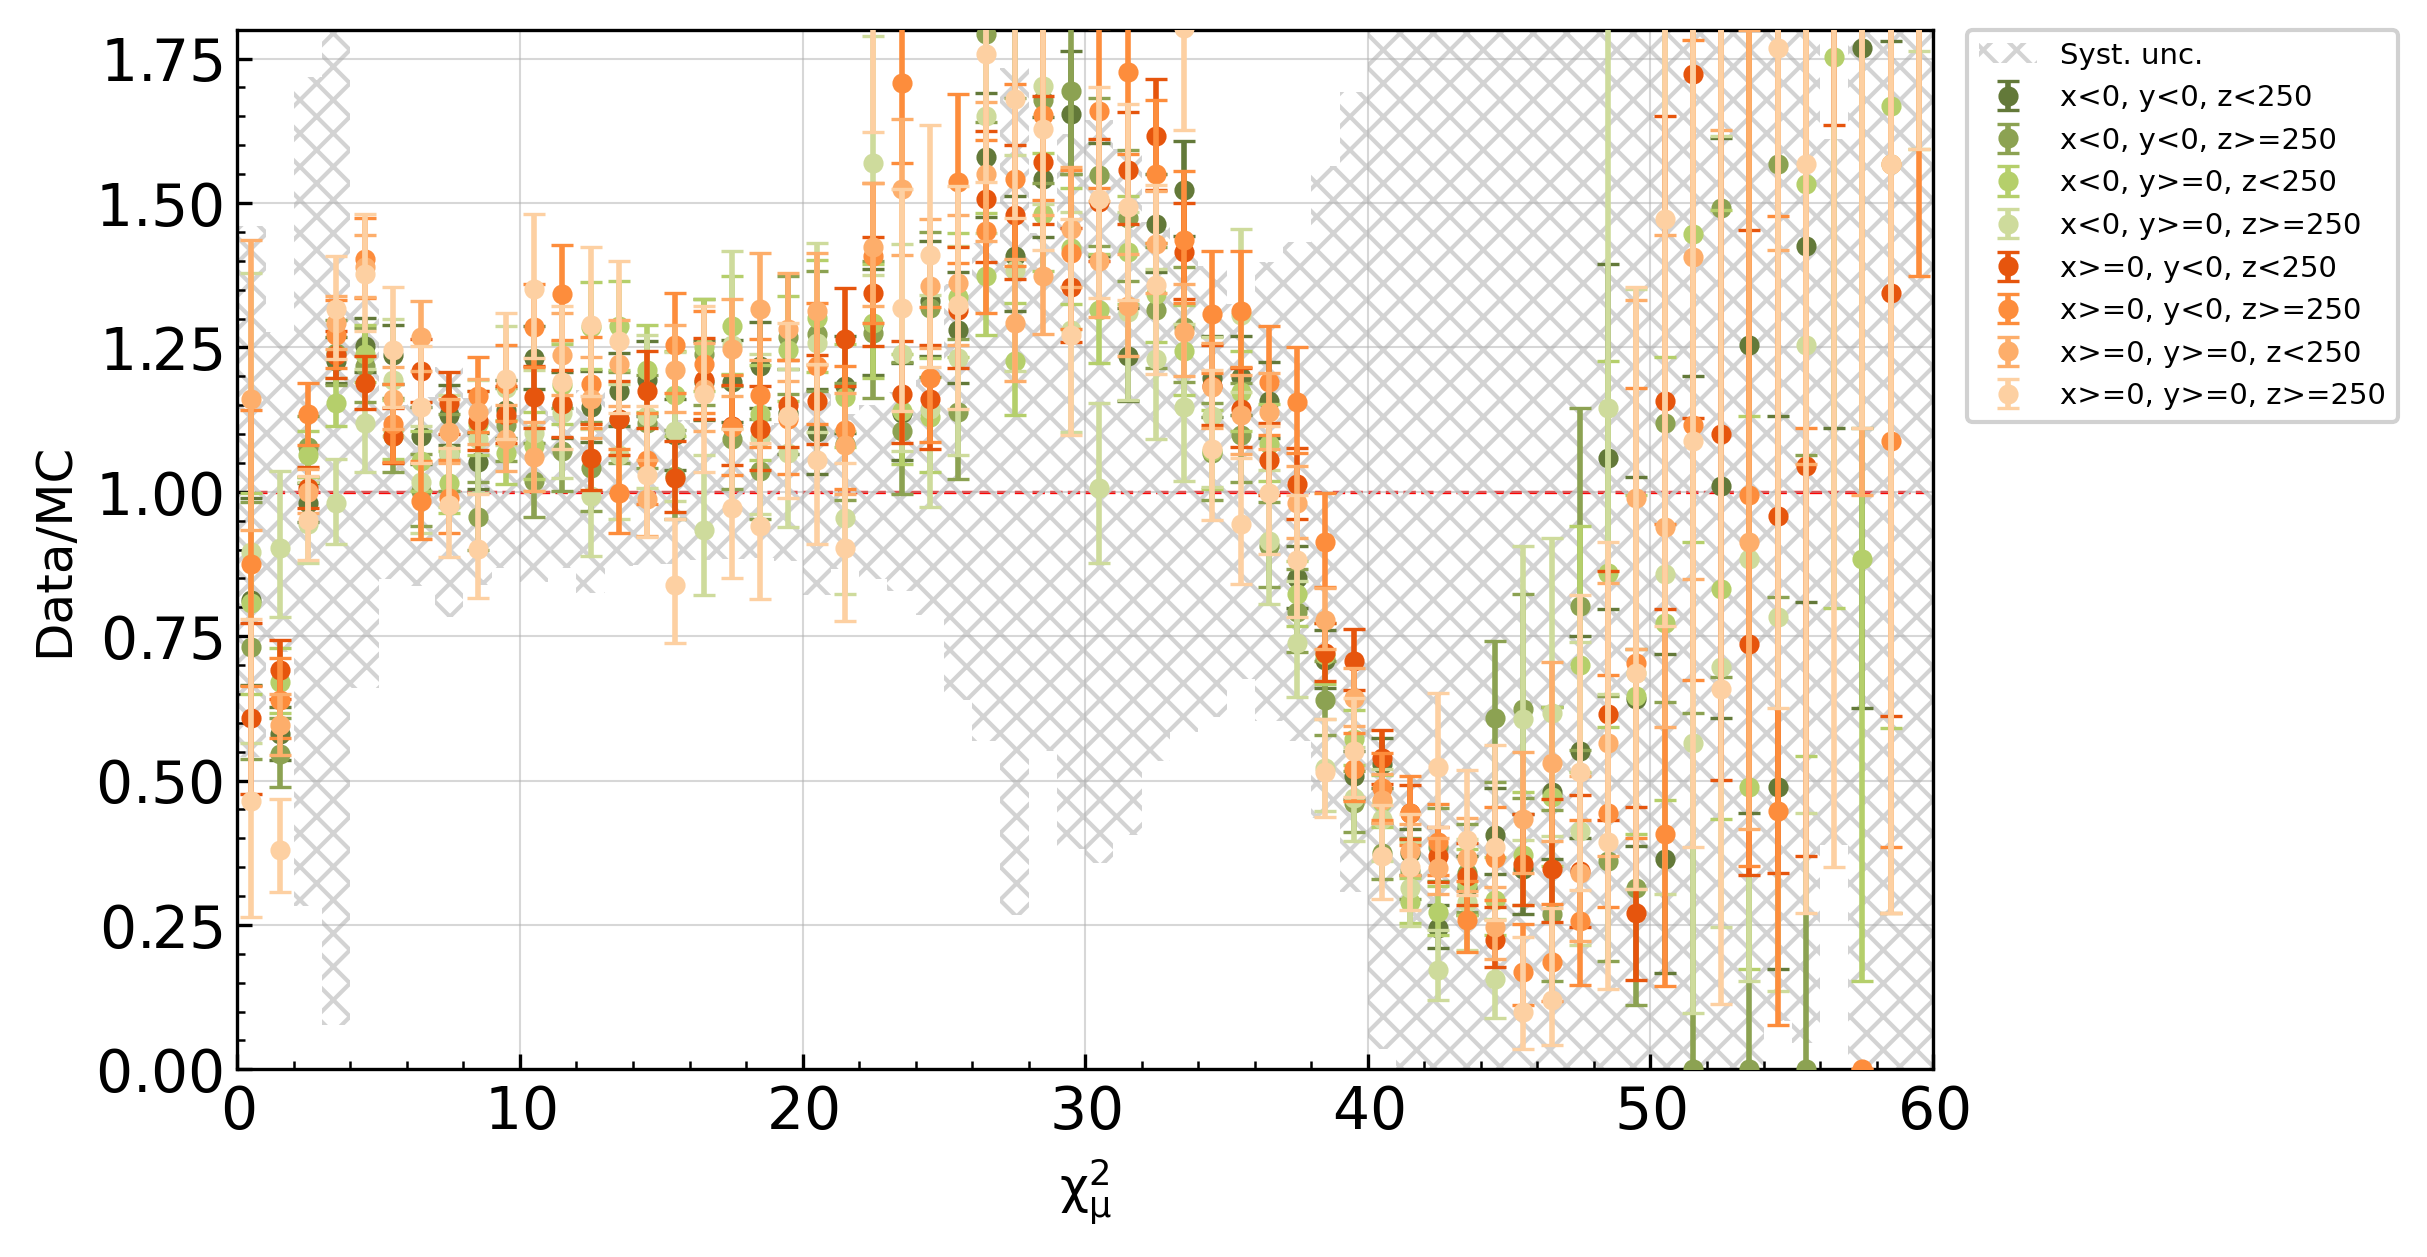

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260702/2prong-trk1trk2_chi2_proton_topology-ratio-octants-overlay-gen1.png.png


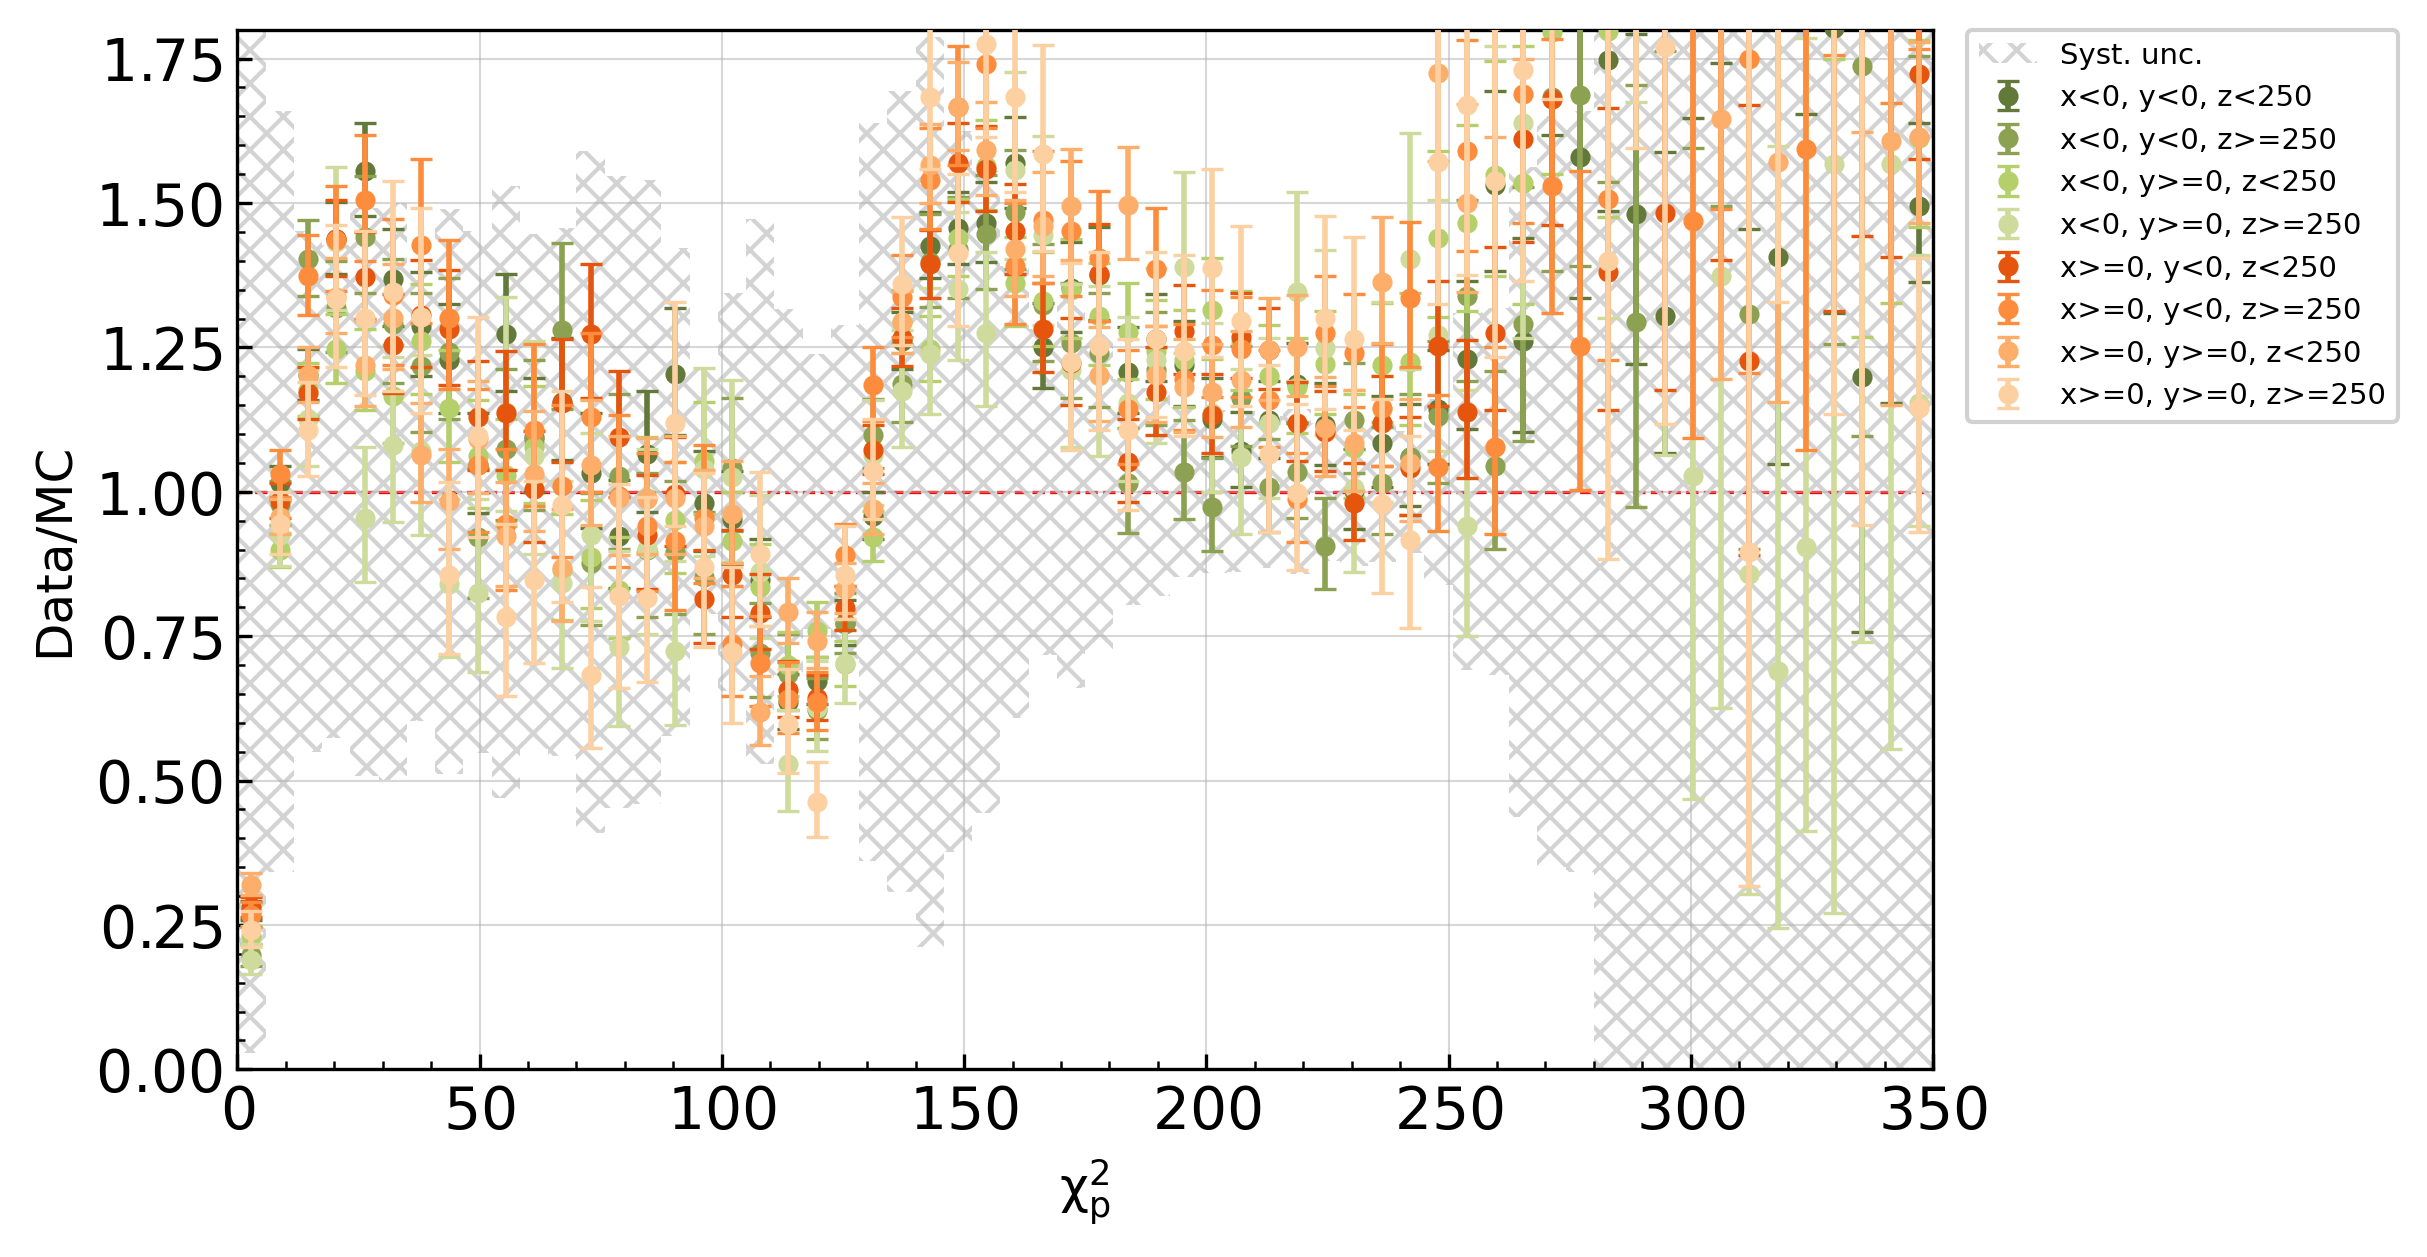

In [34]:
# All octant Data/MC ratio spectra on one plot (syst from npy only, no cosmic add-on)
plot_type = "topology"

plot_octants_ratio_overlay_both_trks(
    plot_type,
    avg_chi2_var_config("trk1", "mu"),
    avg_chi2_var_config("trk2", "mu"),
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    var_save_name="trk1trk2_chi2_mu",
    var_label=r"$\mathrm{\chi^{2}_{\mu}}$",
    suffix="-gen1",
);

plot_octants_ratio_overlay_both_trks(
    plot_type,
    avg_chi2_var_config("trk1", "proton"),
    avg_chi2_var_config("trk2", "proton"),
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    var_save_name="trk1trk2_chi2_proton",
    var_label=r"$\mathrm{\chi^{2}_{p}}$",
    suffix="-gen1",
);

In [ ]:
plot_type = "topology"

# NOTE: the avg chi2 columns and the matching var configs (avg_chi2_var_config)
# are defined in the definitions cell; the combined trk1+trk2 avg chi2_proton
# octant plot is produced in the cell above.

# for i in range(8):
#     save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
#     plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_evt_df_octants[i],
#                             data_df=data_evt_df_octants[i],
#                             intime_df=intime_evt_df_octants[i],
#                             dirt_df=dirt_evt_df_octants[i],
#                             syst=get_wiremod_total_frac_cov(var_config),
#                             load_syst_from_summary=False,
#                             syst_decomp=False,
#                             ratio=True,
#                             ax_ylim_ratio=1.8,
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig,
#                             save_name=save_name)

# var_config_evt = VariableConfig.chi2_mu()
# var_config_trk = VariableConfig.chi2_mu_trk1()
# syst = get_syst(mc_evt_df_octants_gen1, dirt_evt_df_octants_gen1, intime_evt_df_octants_gen1, offbeam_evt_df_octants_gen1, var_config_evt, var_config_trk)

In [ ]:
var_config = VariableConfig.trk1_end_x()

In [ ]:
plot_type = "topology"

var_config = VariableConfig.trk1_end_x()

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants,
    data_evt_df_octants,
    intime_evt_df_octants,
    dirt_octants=dirt_evt_df_octants,
)


plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
);

In [ ]:
# turn off RuntimeWaning
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [ ]:
plot_type = "topology"

# var_config = VariableConfig.costh_trk1_trk2()
var_config = VariableConfig.trk1_len()

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    offbeam_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

In [ ]:
plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

In [ ]:
cut_bin(mc_evt_df_octants_gen1[0])

In [ ]:
def cut_bin(df):
    return df

plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

def cut_bin(df):
    this_var_config = VariableConfig.trk2_direction_phi()
    return df[(np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 90) > 10)] # & (np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 0) > 10)]

plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);


def cut_bin(df):
    this_var_config = VariableConfig.trk2_chi2_mu()
    return df[(df[this_var_config.var_evt_reco_col] > 0)]

plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

In [ ]:
def cut_bin(df):
    return df

plot_type = "topology"

# var_config = VariableConfig.trk1_chi2_mu()
# plot_all_octants(
#     plot_type,
#     var_config,
#     [cut_bin(df) for df in mc_evt_df_octants_gen1],
#     [cut_bin(df) for df in data_evt_df_octants_gen1],
#     [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
#     dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
#     suffix="-gen1",
#     syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
# );

var_config = VariableConfig.trk2_chi2_mu()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

def cut_bin(df):
    this_var_config = VariableConfig.trk2_chi2_mu()
    return df[(np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 90) > 10)] # & (np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 0) > 10)]

plot_type = "topology"

# var_config = VariableConfig.trk1_chi2_mu()
# plot_all_octants(
#     plot_type,
#     var_config,
#     [cut_bin(df) for df in mc_evt_df_octants_gen1],
#     [cut_bin(df) for df in data_evt_df_octants_gen1],
#     [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
#     dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
#     suffix="-gen1",
#     syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
# );

var_config = VariableConfig.trk2_chi2_mu()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

In [ ]:
cut_dfs = [cut_bin(df) for df in mc_evt_df_octants_gen1]
for oidx in range(8):
    print(oidx, (data_evt_df_octants_gen1[oidx].trk2.pfp.trk.chi2pid.I2.chi2_muon == 0).sum() / len(data_evt_df_octants_gen1[oidx]))
    print(oidx, (cut_dfs[oidx].trk2.pfp.trk.chi2pid.I2.chi2_muon == 0).sum() / len(cut_dfs[oidx]))
    print( " ------  ")


In [ ]:
plot_type = "topology"

var_config = VariableConfig.trk2_direction_phi()

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants,
    data_evt_df_octants,
    intime_evt_df_octants,
    dirt_octants=dirt_evt_df_octants,
)

In [ ]:
save_fig_dir

In [ ]:


# for i in range(8):
#     save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
#     plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_evt_df_octants[i],
#                             data_df=data_evt_df_octants[i],
#                             intime_df=intime_evt_df_octants[i],
#                             dirt_df=dirt_evt_df_octants[i],
#                             syst=get_wiremod_total_frac_cov(var_config),
#                             load_syst_from_summary=False,
#                             syst_decomp=False,
#                             ratio=True,
#                             ax_ylim_ratio=1.8,
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig,
#                             save_name=save_name)